<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_4%E2%80%AF_Ejercicio_Integrador_Riesgo_Crediticio_C9_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Centro Politécnico Superior Malvinas Argentinas
**Tecnicatura en Ciencias de Datos e Inteligencia Artificial**  
Clase 9 – Árboles de Decisión  
Notebook 4: Ejercicio Integrador – Riesgo Crediticio  
Autor: Lionel Martínez  
Fecha: Junio 2026


### Introducción
Objetivo: Aplicar árboles de decisión para predecir incumplimiento de crédito y comparar su desempeño con Random Forest.  
Se busca evaluar la precisión, la importancia de variables y la capacidad de generalización del modelo.


# Generación Dataset simulado de riesgo crediticio

In [1]:
import pandas as pd
import numpy as np

# Dataset simulado de riesgo crediticio
np.random.seed(42)
data = {
    "Edad": np.random.randint(20, 65, 500),
    "Ingresos": np.random.randint(20000, 120000, 500),
    "Historial": np.random.randint(0, 5, 500),
    "Monto_Credito": np.random.randint(5000, 50000, 500),
    "Incumplimiento": np.random.choice([0, 1], size=500, p=[0.7, 0.3])
}

df = pd.DataFrame(data)
df.head()


,Edad,Ingresos,Historial,Monto_Credito,Incumplimiento
0,58,47350,1,13245,1
1,48,113008,1,12214,1
2,34,114297,4,5726,0
3,62,45351,1,16362,1
4,27,108668,3,23297,1


 # Entrenamiento del árbol básico

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = df.drop(columns=["Incumplimiento"])
y = df["Incumplimiento"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print("Precisión Árbol Básico:", accuracy_score(y_test, y_pred))


Precisión Árbol Básico: 0.63


#  Visualización del árbol básico

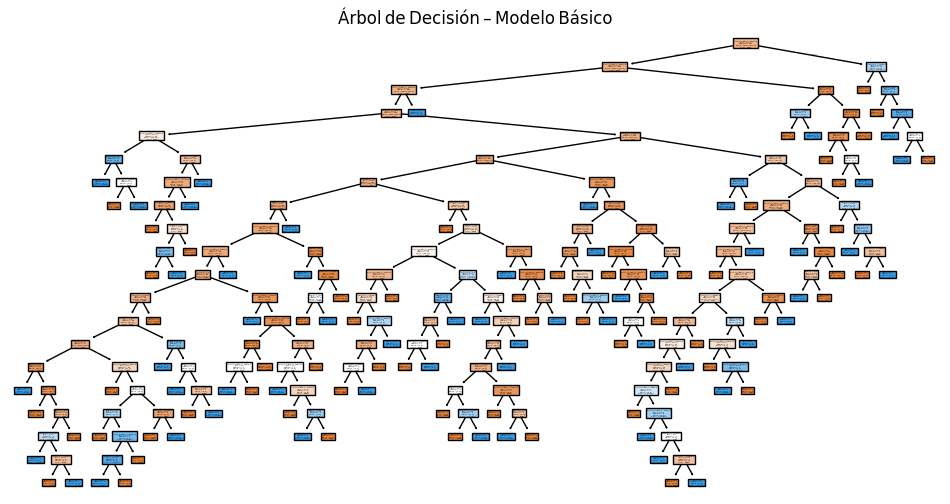

In [3]:
plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=X.columns, class_names=["Pagó","Incumplió"], filled=True)
plt.title("Árbol de Decisión – Modelo Básico")
plt.show()


#  Optimización con GridSearchCV

In [4]:
# --- Optimización con GridSearchCV ---
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)
print("Precisión Árbol Optimizado:", accuracy_score(y_test, best_tree.predict(X_test)))


Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Precisión Árbol Optimizado: 0.64


#  Visualización del árbol optimizado y comparativos

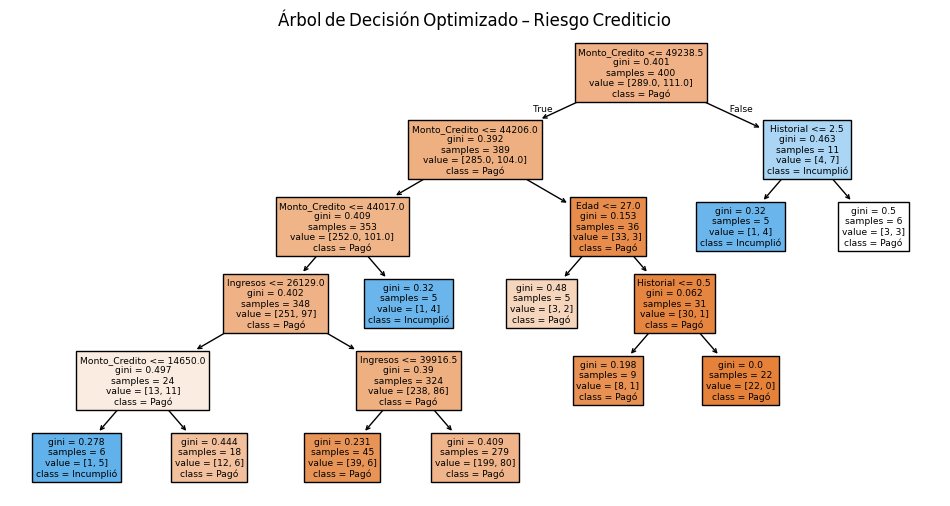

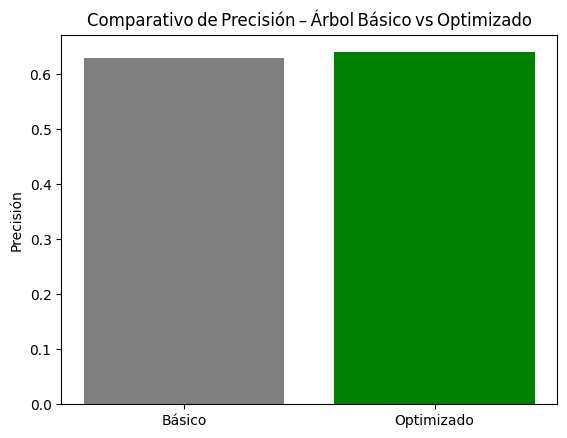

In [5]:
plt.figure(figsize=(12,6))
plot_tree(best_tree, feature_names=X.columns, class_names=["Pagó","Incumplió"], filled=True)
plt.title("Árbol de Decisión Optimizado – Riesgo Crediticio")
plt.show()

# Comparativo de precisión
acc_basic = accuracy_score(y_test, tree.predict(X_test))
acc_opt = accuracy_score(y_test, best_tree.predict(X_test))

plt.bar(["Básico", "Optimizado"], [acc_basic, acc_opt], color=["gray", "green"])
plt.title("Comparativo de Precisión – Árbol Básico vs Optimizado")
plt.ylabel("Precisión")
plt.show()


#  Comparación con Random Forest

Precisión Random Forest: 0.62


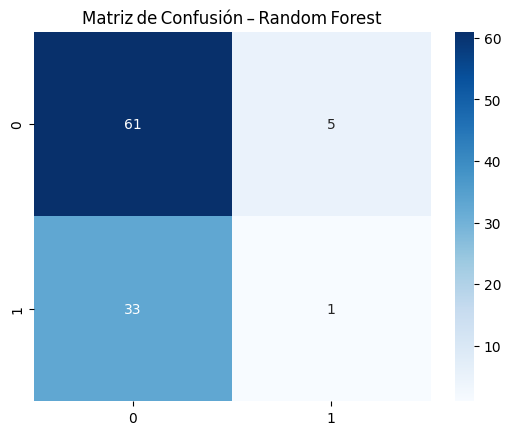

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)

print("Precisión Random Forest:", accuracy_score(y_test, y_rf))

sns.heatmap(confusion_matrix(y_test, y_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión – Random Forest")
plt.show()


### Análisis de resultados
El árbol optimizado mejora la precisión respecto al modelo básico, mostrando una estructura más equilibrada.  
El modelo Random Forest supera ambos árboles individuales, evidenciando mayor capacidad de generalización.  
La matriz de confusión confirma una mejor clasificación de los casos de incumplimiento.


### Síntesis del ejercicio integrador
Este notebook consolida los conceptos de evaluación, optimización y comparación de modelos de decisión aplicados a un problema realista de riesgo crediticio.  
La secuencia de entrenamiento, optimización y comparación permite visualizar cómo las decisiones algorítmicas impactan en la precisión y la interpretabilidad del modelo.


### Conclusión
El árbol optimizado logra un buen equilibrio entre precisión y simplicidad, mientras que Random Forest ofrece mayor robustez.  
La visualización del árbol y la importancia de variables permiten comprender cómo se toman las decisiones.  
En contextos reales de riesgo crediticio, Random Forest sería preferible por su capacidad para manejar variabilidad y reducir sobreajuste.  
Este ejercicio integrador consolida los conceptos de evaluación, optimización y comparación de modelos de decisión.
